In [1]:
# Importamos las librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Cargamos el archivo
data = pd.read_excel("SDC.xlsx")

data.head(20)

,Ventas,Unnamed: 1,12,7,8,13,6,21,17,17.1,...,38,30.2,41.1,41.2,35,Unnamed: 32,Unnamed: 33,Unnamed: 34,Unnamed: 35,Unnamed: 36
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Indicador,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24",...,"Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26",Total 2024,Total 2025,Total 2026,NaN,NaN
2,Generadas,5,6,11,23,26,43,55,36,56,...,85,74,95,82,32,519,1178,450,1697.0,0.392457
3,Aprobadas,1,2,7,14,8,13,30,19,26,...,41,42,44,35,12,215,451,201,666.0,0.509009
4,Condicionadas,0,0,1,0,4,0,3,0,1,...,14,16,17,10,9,100,287,102,387.0,NaN
5,Rechazadas,4,4,4,9,14,22,17,13,13,...,30,16,30,33,9,163,392,137,555.0,NaN
6,Formalizadas,1,1,5,11,3,6,17,9,7,...,18,16,19,13,4,105,234,91,339.0,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,% de Aprobación,0.2,0.333333,0.636364,0.608696,0.307692,0.302326,0.545455,0.527778,0.464286,...,0.482353,0.567568,0.463158,0.426829,0.375,0.414258,0.382852,0.446667,NaN,NaN
9,% de Formalizacion,1,0.5,0.714286,0.785714,0.375,0.461538,0.566667,0.473684,0.269231,...,0.439024,0.380952,0.431818,0.371429,0.333333,0.488372,0.518847,0.452736,NaN,NaN


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Ventas       34 non-null     str    
 1   Unnamed: 1   23 non-null     object 
 2   12           23 non-null     object 
 3   7            23 non-null     object 
 4   8            23 non-null     object 
 5   13           23 non-null     object 
 6   6            23 non-null     object 
 7   21           23 non-null     object 
 8   17           23 non-null     object 
 9   17.1         22 non-null     object 
 10  23           23 non-null     object 
 11  22           22 non-null     object 
 12  32           22 non-null     object 
 13  26           22 non-null     object 
 14  20           22 non-null     object 
 15  30           22 non-null     object 
 16  30.1         22 non-null     object 
 17  34           28 non-null     object 
 18  40           27 non-null     object 
 19  36           28 non-n

In [4]:
# Tabla de indicadores
indicadores = pd.read_excel(
    "SDC.xlsx",
    sheet_name="Hoja1",
    header=2,
    nrows=8,
    usecols="A:AI"
)

# Eliminamos la fila completamente vacía
indicadores = indicadores.dropna(how="all")

indicadores

,Indicador,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24",...,"Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26",Total 2024,Total 2025,Total 2026
0,Generadas,5.0,6.000000,11.000000,23.000000,26.000000,43.000000,55.000000,36.000000,56.000000,...,113.000000,83.000000,85.000000,74.000000,95.000000,82.000000,32.000000,519.000000,1178.000000,450.000000
1,Aprobadas,1.0,2.000000,7.000000,14.000000,8.000000,13.000000,30.000000,19.000000,26.000000,...,37.000000,37.000000,41.000000,42.000000,44.000000,35.000000,12.000000,215.000000,451.000000,201.000000
2,Condicionadas,0.0,0.000000,1.000000,0.000000,4.000000,0.000000,3.000000,0.000000,1.000000,...,34.000000,21.000000,14.000000,16.000000,17.000000,10.000000,9.000000,100.000000,287.000000,102.000000
3,Rechazadas,4.0,4.000000,4.000000,9.000000,14.000000,22.000000,17.000000,13.000000,13.000000,...,36.000000,25.000000,30.000000,16.000000,30.000000,33.000000,9.000000,163.000000,392.000000,137.000000
4,Formalizadas,1.0,1.000000,5.000000,11.000000,3.000000,6.000000,17.000000,9.000000,7.000000,...,21.000000,17.000000,18.000000,16.000000,19.000000,13.000000,4.000000,105.000000,234.000000,91.000000
6,% de Aprobación,0.2,0.333333,0.636364,0.608696,0.307692,0.302326,0.545455,0.527778,0.464286,...,0.327434,0.445783,0.482353,0.567568,0.463158,0.426829,0.375000,0.414258,0.382852,0.446667
7,% de Formalizacion,1.0,0.500000,0.714286,0.785714,0.375000,0.461538,0.566667,0.473684,0.269231,...,0.567568,0.459459,0.439024,0.380952,0.431818,0.371429,0.333333,0.488372,0.518847,0.452736


In [5]:
# Quitamos las columnas de totales
indicadores_cuantitativos = indicadores.iloc[:, 0:32]

# Ponemos los indicadores como columnas
indicadores_cuantitativos = indicadores_cuantitativos.set_index(
    "Indicador"
).T

indicadores_cuantitativos

Indicador,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
"Enero, 24",5.0,1.0,0.0,4.0,1.0,0.200000,1.000000
"Febrero, 24",6.0,2.0,0.0,4.0,1.0,0.333333,0.500000
"Marzo, 24",11.0,7.0,1.0,4.0,5.0,0.636364,0.714286
"Abril, 24",23.0,14.0,0.0,9.0,11.0,0.608696,0.785714
"Mayo, 24",26.0,8.0,4.0,14.0,3.0,0.307692,0.375000
"Junio, 24",43.0,13.0,0.0,22.0,6.0,0.302326,0.461538
"Julio, 24",55.0,30.0,3.0,17.0,17.0,0.545455,0.566667
"Agosto, 24",36.0,19.0,0.0,13.0,9.0,0.527778,0.473684
"Septiembre, 24",56.0,26.0,1.0,13.0,7.0,0.464286,0.269231
"Octubre, 24",79.0,31.0,32.0,12.0,14.0,0.392405,0.451613


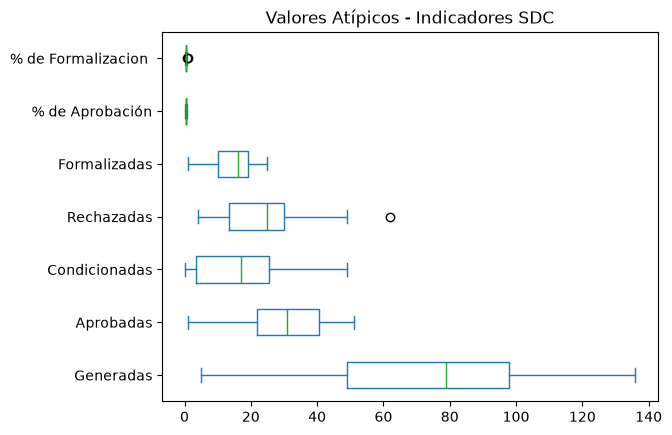

In [6]:
# Diagrama de caja antes del tratamiento
indicadores_cuantitativos.plot(
    kind="box",
    vert=False
)

plt.title("Valores Atípicos - Indicadores SDC")
plt.show()

In [7]:
y = indicadores_cuantitativos

# Calculamos los cuartiles
percentile25 = y.quantile(0.25)
percentile75 = y.quantile(0.75)

iqr = percentile75 - percentile25

print("Q1:")
print(percentile25)

print("\nQ3:")
print(percentile75)

print("\nIQR:")
print(iqr)

Q1:
Indicador
Generadas              49.000000
Aprobadas              22.000000
Condicionadas           3.500000
Rechazadas             13.500000
Formalizadas           10.000000
% de Aprobación         0.335145
% de Formalizacion      0.441734
Name: 0.25, dtype: float64

Q3:
Indicador
Generadas              98.000000
Aprobadas              40.500000
Condicionadas          25.500000
Rechazadas             30.000000
Formalizadas           19.000000
% de Aprobación         0.478290
% de Formalizacion      0.563333
Name: 0.75, dtype: float64

IQR:
Indicador
Generadas              49.000000
Aprobadas              18.500000
Condicionadas          22.000000
Rechazadas             16.500000
Formalizadas            9.000000
% de Aprobación         0.143145
% de Formalizacion      0.121599
dtype: float64


In [8]:
# Calculamos los límites
Limite_Superior_iqr = percentile75 + 1.5 * iqr
Limite_Inferior_iqr = percentile25 - 1.5 * iqr

print("Límite Superior:")
print(Limite_Superior_iqr)

print("\nLímite Inferior:")
print(Limite_Inferior_iqr)

Límite Superior:
Indicador
Generadas              171.500000
Aprobadas               68.250000
Condicionadas           58.500000
Rechazadas              54.750000
Formalizadas            32.500000
% de Aprobación          0.693007
% de Formalizacion       0.745732
dtype: float64

Límite Inferior:
Indicador
Generadas             -24.500000
Aprobadas              -5.750000
Condicionadas         -29.500000
Rechazadas            -11.250000
Formalizadas           -3.500000
% de Aprobación         0.120428
% de Formalizacion      0.259336
dtype: float64


In [9]:
# Convertimos los valores atípicos en valores nulos
indicadores_iqr = indicadores_cuantitativos[
    (y <= Limite_Superior_iqr) &
    (y >= Limite_Inferior_iqr)
]

indicadores_iqr

Indicador,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
"Enero, 24",5.0,1.0,0.0,4.0,1.0,0.200000,NaN
"Febrero, 24",6.0,2.0,0.0,4.0,1.0,0.333333,0.500000
"Marzo, 24",11.0,7.0,1.0,4.0,5.0,0.636364,0.714286
"Abril, 24",23.0,14.0,0.0,9.0,11.0,0.608696,NaN
"Mayo, 24",26.0,8.0,4.0,14.0,3.0,0.307692,0.375000
"Junio, 24",43.0,13.0,0.0,22.0,6.0,0.302326,0.461538
"Julio, 24",55.0,30.0,3.0,17.0,17.0,0.545455,0.566667
"Agosto, 24",36.0,19.0,0.0,13.0,9.0,0.527778,0.473684
"Septiembre, 24",56.0,26.0,1.0,13.0,7.0,0.464286,0.269231
"Octubre, 24",79.0,31.0,32.0,12.0,14.0,0.392405,0.451613


In [10]:
# Contamos los valores atípicos encontrados
indicadores_iqr.isnull().sum()

Indicador
Generadas              0
Aprobadas              0
Condicionadas          0
Rechazadas             1
Formalizadas           0
% de Aprobación        0
% de Formalizacion     2
dtype: int64

In [11]:
indicadores_limpios = indicadores_iqr.copy()

# Reemplazamos los valores atípicos por la mediana
indicadores_limpios = indicadores_limpios.fillna(
    indicadores_iqr.median()
)

indicadores_limpios

Indicador,Generadas,Aprobadas,Condicionadas,Rechazadas,Formalizadas,% de Aprobación,% de Formalizacion
"Enero, 24",5.0,1.0,0.0,4.0,1.0,0.200000,0.475000
"Febrero, 24",6.0,2.0,0.0,4.0,1.0,0.333333,0.500000
"Marzo, 24",11.0,7.0,1.0,4.0,5.0,0.636364,0.714286
"Abril, 24",23.0,14.0,0.0,9.0,11.0,0.608696,0.475000
"Mayo, 24",26.0,8.0,4.0,14.0,3.0,0.307692,0.375000
"Junio, 24",43.0,13.0,0.0,22.0,6.0,0.302326,0.461538
"Julio, 24",55.0,30.0,3.0,17.0,17.0,0.545455,0.566667
"Agosto, 24",36.0,19.0,0.0,13.0,9.0,0.527778,0.473684
"Septiembre, 24",56.0,26.0,1.0,13.0,7.0,0.464286,0.269231
"Octubre, 24",79.0,31.0,32.0,12.0,14.0,0.392405,0.451613


In [12]:
indicadores_limpios.isnull().sum()

Indicador
Generadas              0
Aprobadas              0
Condicionadas          0
Rechazadas             0
Formalizadas           0
% de Aprobación        0
% de Formalizacion     0
dtype: int64

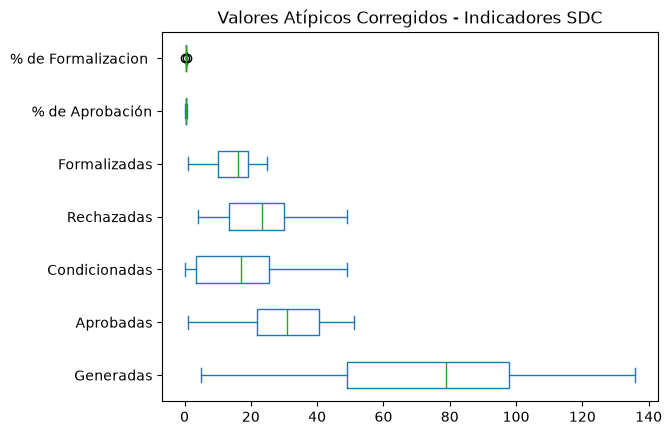

In [13]:
# Diagrama de caja después de la limpieza
indicadores_limpios.plot(
    kind="box",
    vert=False
)

plt.title("Valores Atípicos Corregidos - Indicadores SDC")
plt.show()

In [14]:
# Verificamos si todavía existen valores atípicos

y2 = indicadores_limpios

Q1_final = y2.quantile(0.25)
Q3_final = y2.quantile(0.75)
IQR_final = Q3_final - Q1_final

Limite_Superior_final = Q3_final + 1.5 * IQR_final
Limite_Inferior_final = Q1_final - 1.5 * IQR_final

valores_atipicos_finales = (
    (y2 > Limite_Superior_final) |
    (y2 < Limite_Inferior_final)
).sum()

print(valores_atipicos_finales)

Indicador
Generadas              0
Aprobadas              0
Condicionadas          0
Rechazadas             0
Formalizadas           0
% de Aprobación        0
% de Formalizacion     2
dtype: int64


In [15]:

y2 = indicadores_limpios

Q1_final = y2.quantile(0.25)
Q3_final = y2.quantile(0.75)
IQR_final = Q3_final - Q1_final

Limite_Superior_final = Q3_final + 1.5 * IQR_final
Limite_Inferior_final = Q1_final - 1.5 * IQR_final

indicadores_final = indicadores_limpios[
    (y2 <= Limite_Superior_final) &
    (y2 >= Limite_Inferior_final)
]

In [16]:
# Verificamos los valores atípicos usando los límites originales

valores_atipicos_restantes = (
    (indicadores_limpios > Limite_Superior_iqr) |
    (indicadores_limpios < Limite_Inferior_iqr)
).sum()

print(valores_atipicos_restantes)

Indicador
Generadas              0
Aprobadas              0
Condicionadas          0
Rechazadas             0
Formalizadas           0
% de Aprobación        0
% de Formalizacion     0
dtype: int64


In [17]:
# Obtenemos los nombres de los meses
meses = indicadores.columns[1:32].tolist()

# Cargamos la tabla de financieras
financieras = pd.read_excel(
    "SDC.xlsx",
    sheet_name="Hoja1",
    header=14,
    nrows=15,
    usecols="A:AH"
)

# Eliminamos filas sin nombre de financiera
financieras = financieras.dropna(subset=["Financiera"])

# Asignamos los nombres correctos de columnas
financieras.columns = (
    ["Financiera"]
    + meses
    + ["TOTAL", "% PARTICIPACION"]
)

financieras

,Financiera,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24",...,"Diciembre, 25.1","Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26",TOTAL,% PARTICIPACION
1,ABC,-,-,-,-,-,-,-,-,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.000518
2,Afirme,-,-,-,-,-,-,-,-,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.0,0.062727
3,Banorte,-,-,-,-,-,-,-,-,1,...,69,53.0,33.0,33.0,33.0,34.0,15.0,10.0,790.0,0.409539
4,BBVA,-,-,-,-,-,-,-,-,12,...,6,7.0,10.0,12.0,7.0,11.0,16.0,3.0,202.0,0.104717
5,Ensueño,-,-,-,-,-,-,-,-,-,...,22,9.0,4.0,3.0,1.0,8.0,8.0,7.0,144.0,0.074650
6,FinanMadrid,-,-,-,-,-,-,-,-,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.001037
7,INBURSA,-,-,-,-,-,-,-,-,-,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.000000
8,MSTART,-,-,-,-,-,-,-,-,-,...,3,12.0,12.0,9.0,5.0,11.0,6.0,1.0,156.0,0.080871
9,Nexu,-,-,-,-,-,-,-,-,19,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,135.0,0.069984
10,Santander,-,-,-,-,-,-,-,-,1,...,11,26.0,18.0,25.0,21.0,18.0,30.0,7.0,442.0,0.229134


In [18]:
# Quitamos TOTAL y % PARTICIPACION
financieras_cuantitativas = financieras.iloc[:, 0:32].copy()

In [19]:
# Sustituimos guiones y valores nulos por 0
financieras_cuantitativas = financieras_cuantitativas.replace("-", 0)
financieras_cuantitativas = financieras_cuantitativas.fillna(0)

In [20]:
# Ponemos cada financiera como una columna
financieras_cuantitativas = financieras_cuantitativas.set_index(
    "Financiera"
).T

financieras_cuantitativas

Financiera,ABC,Afirme,Banorte,BBVA,Ensueño,FinanMadrid,INBURSA,MSTART,Nexu,Santander,Scotiabank,Sumafin,Bajio,Kuna
"Enero, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Febrero, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Marzo, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Abril, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Mayo, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Junio, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Julio, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Agosto, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Septiembre, 24",0,18,1,12,0,0,0,0,19,1,0,0,0,0
"Octubre, 24",0,23,1,25,0,1,0,0,31,0,0,0,0,0


In [22]:
# Convertimos todos los datos a valores numéricos
financieras_cuantitativas = financieras_cuantitativas.apply(
    pd.to_numeric,
    errors="coerce"
)

# Si queda algún valor nulo, lo reemplazamos por 0
financieras_cuantitativas = financieras_cuantitativas.fillna(0)

financieras_cuantitativas

Financiera,ABC,Afirme,Banorte,BBVA,Ensueño,FinanMadrid,INBURSA,MSTART,Nexu,Santander,Scotiabank,Sumafin,Bajio,Kuna
"Enero, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Febrero, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Marzo, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Abril, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Mayo, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Junio, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Julio, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Agosto, 24",0,0,0,0,0,0,0,0,0,0,0,0,0,0
"Septiembre, 24",0,18,1,12,0,0,0,0,19,1,0,0,0,0
"Octubre, 24",0,23,1,25,0,1,0,0,31,0,0,0,0,0


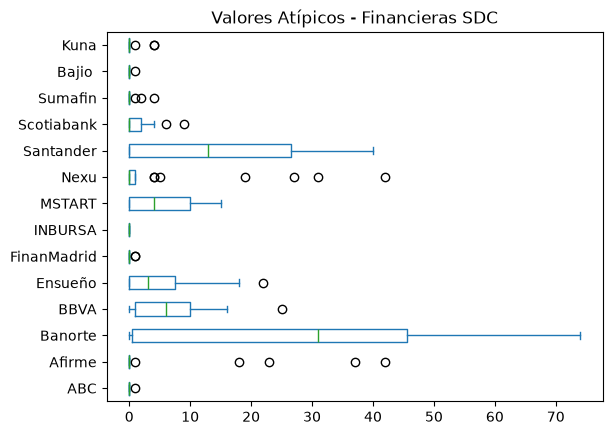

In [23]:
# Diagrama de caja antes del tratamiento
financieras_cuantitativas.plot(
    kind="box",
    vert=False
)

plt.title("Valores Atípicos - Financieras SDC")
plt.show()

In [24]:
y = financieras_cuantitativas

# Calculamos los cuartiles
percentile25 = y.quantile(0.25)
percentile75 = y.quantile(0.75)

iqr = percentile75 - percentile25

print("Q1:")
print(percentile25)

print("\nQ3:")
print(percentile75)

print("\nIQR:")
print(iqr)

Q1:
Financiera
ABC            0.0
Afirme         0.0
Banorte        0.5
BBVA           1.0
Ensueño        0.0
FinanMadrid    0.0
INBURSA        0.0
MSTART         0.0
Nexu           0.0
Santander      0.0
Scotiabank     0.0
Sumafin        0.0
Bajio          0.0
Kuna           0.0
Name: 0.25, dtype: float64

Q3:
Financiera
ABC             0.0
Afirme          0.0
Banorte        45.5
BBVA           10.0
Ensueño         7.5
FinanMadrid     0.0
INBURSA         0.0
MSTART         10.0
Nexu            1.0
Santander      26.5
Scotiabank      2.0
Sumafin         0.0
Bajio           0.0
Kuna            0.0
Name: 0.75, dtype: float64

IQR:
Financiera
ABC             0.0
Afirme          0.0
Banorte        45.0
BBVA            9.0
Ensueño         7.5
FinanMadrid     0.0
INBURSA         0.0
MSTART         10.0
Nexu            1.0
Santander      26.5
Scotiabank      2.0
Sumafin         0.0
Bajio           0.0
Kuna            0.0
dtype: float64


In [25]:
# Calculamos los límites con IQR

Limite_Superior_iqr = percentile75 + 1.5 * iqr
Limite_Inferior_iqr = percentile25 - 1.5 * iqr

print("Límite Superior:")
print(Limite_Superior_iqr)

print("\nLímite Inferior:")
print(Limite_Inferior_iqr)

Límite Superior:
Financiera
ABC              0.00
Afirme           0.00
Banorte        113.00
BBVA            23.50
Ensueño         18.75
FinanMadrid      0.00
INBURSA          0.00
MSTART          25.00
Nexu             2.50
Santander       66.25
Scotiabank       5.00
Sumafin          0.00
Bajio            0.00
Kuna             0.00
dtype: float64

Límite Inferior:
Financiera
ABC             0.00
Afirme          0.00
Banorte       -67.00
BBVA          -12.50
Ensueño       -11.25
FinanMadrid     0.00
INBURSA         0.00
MSTART        -15.00
Nexu           -1.50
Santander     -39.75
Scotiabank     -3.00
Sumafin         0.00
Bajio           0.00
Kuna            0.00
dtype: float64


In [26]:
# Convertimos los valores atípicos en valores nulos

financieras_iqr = financieras_cuantitativas[
    (y <= Limite_Superior_iqr) &
    (y >= Limite_Inferior_iqr)
]

financieras_iqr

Financiera,ABC,Afirme,Banorte,BBVA,Ensueño,FinanMadrid,INBURSA,MSTART,Nexu,Santander,Scotiabank,Sumafin,Bajio,Kuna
"Enero, 24",0.0,0.0,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0
"Febrero, 24",0.0,0.0,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0
"Marzo, 24",0.0,0.0,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0
"Abril, 24",0.0,0.0,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0
"Mayo, 24",0.0,0.0,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0
"Junio, 24",0.0,0.0,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0
"Julio, 24",0.0,0.0,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0
"Agosto, 24",0.0,0.0,0,0.0,0.0,0.0,0,0,0.0,0,0.0,0.0,0.0,0.0
"Septiembre, 24",0.0,NaN,1,12.0,0.0,0.0,0,0,NaN,1,0.0,0.0,0.0,0.0
"Octubre, 24",0.0,NaN,1,NaN,0.0,NaN,0,0,NaN,0,0.0,0.0,0.0,0.0


In [27]:
# Contamos los valores atípicos encontrados

financieras_iqr.isnull().sum()

Financiera
ABC            1
Afirme         5
Banorte        0
BBVA           1
Ensueño        1
FinanMadrid    2
INBURSA        0
MSTART         0
Nexu           7
Santander      0
Scotiabank     2
Sumafin        3
Bajio          1
Kuna           3
dtype: int64

In [28]:
# Revisamos qué financieras tienen IQR igual a 0
iqr > 0
print(iqr)

Financiera
ABC             0.0
Afirme          0.0
Banorte        45.0
BBVA            9.0
Ensueño         7.5
FinanMadrid     0.0
INBURSA         0.0
MSTART         10.0
Nexu            1.0
Santander      26.5
Scotiabank      2.0
Sumafin         0.0
Bajio           0.0
Kuna            0.0
dtype: float64


In [29]:
# Creamos una copia de los datos originales
financieras_limpias = financieras_cuantitativas.copy()

# Reemplazamos los outliers solamente en columnas con IQR mayor a 0
for columna in financieras_cuantitativas.columns:
    if iqr[columna] > 0:
        financieras_limpias[columna] = financieras_iqr[columna].fillna(
            financieras_iqr[columna].median()
        )

In [30]:
financieras_limpias.isnull().sum()

Financiera
ABC            0
Afirme         0
Banorte        0
BBVA           0
Ensueño        0
FinanMadrid    0
INBURSA        0
MSTART         0
Nexu           0
Santander      0
Scotiabank     0
Sumafin        0
Bajio          0
Kuna           0
dtype: int64

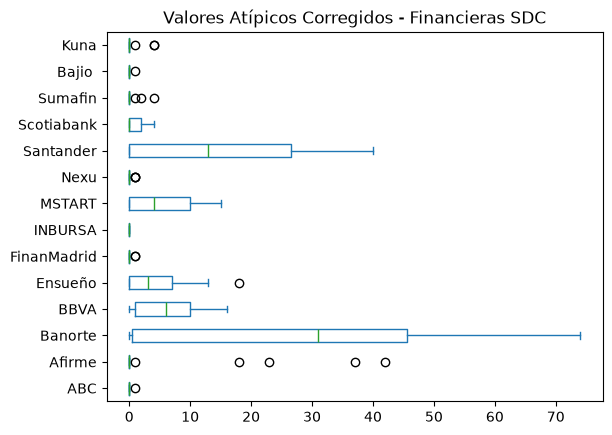

In [ ]:
# Boxplot después del tratamiento
financieras_limpias.plot(
    kind="box",
    vert=False
)

plt.title("Valores Atípicos Corregidos - Financieras SDC")
plt.show()

In [32]:
# Verificamos los valores atípicos restantes

for columna in financieras_cuantitativas.columns:
    if iqr[columna] > 0:
        restantes = (
            (financieras_limpias[columna] > Limite_Superior_iqr[columna]) |
            (financieras_limpias[columna] < Limite_Inferior_iqr[columna])
        ).sum()

        print(columna, ":", restantes)

Banorte : 0
BBVA : 0
Ensueño : 0
MSTART : 0
Nexu : 0
Santander : 0
Scotiabank : 0


In [33]:
# Tabla de motivos de SDC no autorizadas
no_autorizadas = pd.read_excel(
    "SDC.xlsx",
    sheet_name="Hoja1",
    header=32,
    nrows=4,
    usecols="A:AG"
)

# Cambiamos el nombre de la primera columna
no_autorizadas = no_autorizadas.rename(
    columns={no_autorizadas.columns[0]: "Motivo"}
)

no_autorizadas

,Motivo,"Enero, 24","Febrero, 24","Marzo, 24","Abril, 24","Mayo, 24","Junio, 24","Julio, 24","Agosto, 24","Septiembre, 24",...,"Noviembre, 25","Diciembre, 25.1","Enero, 26","Febrero, 26","Marzo, 26","Abril, 26","Mayo,26","Junio, 26","Julio,26",Total
0,Mal Buro,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,26,27.0,33,19,15,12.0,12,22,NaN,311
1,Score bajo,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,7.0,5,3,10,4.0,10,4,NaN,66
2,Capacidad de pago,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4,NaN,0,2,3,NaN,6,6,NaN,17
3,Otros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,NaN,0,1,2,NaN,1,1,NaN,7


In [34]:
# Ponemos cada motivo como una columna
no_autorizadas_cuantitativas = no_autorizadas.set_index(
    "Motivo"
).T

no_autorizadas_cuantitativas

Motivo,Mal Buro,Score bajo,Capacidad de pago,Otros
"Enero, 24",NaN,NaN,NaN,NaN
"Febrero, 24",NaN,NaN,NaN,NaN
"Marzo, 24",NaN,NaN,NaN,NaN
"Abril, 24",NaN,NaN,NaN,NaN
"Mayo, 24",NaN,NaN,NaN,NaN
"Junio, 24",NaN,NaN,NaN,NaN
"Julio, 24",NaN,NaN,NaN,NaN
"Agosto, 24",NaN,NaN,NaN,NaN
"Septiembre, 24",NaN,NaN,NaN,NaN
"Octubre, 24",NaN,NaN,NaN,NaN


In [35]:
# Convertimos los datos a valores numéricos
no_autorizadas_cuantitativas = no_autorizadas_cuantitativas.apply(
    pd.to_numeric,
    errors="coerce"
)

# Los valores vacíos se reemplazan por 0
no_autorizadas_cuantitativas = no_autorizadas_cuantitativas.fillna(0)

no_autorizadas_cuantitativas

Motivo,Mal Buro,Score bajo,Capacidad de pago,Otros
"Enero, 24",0.0,0.0,0.0,0.0
"Febrero, 24",0.0,0.0,0.0,0.0
"Marzo, 24",0.0,0.0,0.0,0.0
"Abril, 24",0.0,0.0,0.0,0.0
"Mayo, 24",0.0,0.0,0.0,0.0
"Junio, 24",0.0,0.0,0.0,0.0
"Julio, 24",0.0,0.0,0.0,0.0
"Agosto, 24",0.0,0.0,0.0,0.0
"Septiembre, 24",0.0,0.0,0.0,0.0
"Octubre, 24",0.0,0.0,0.0,0.0


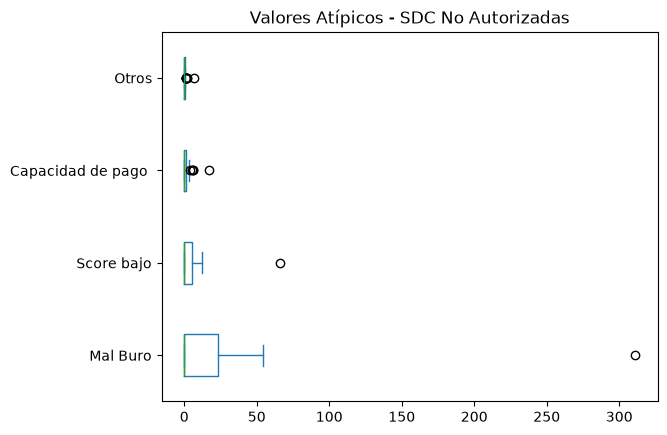

In [36]:
# Diagrama de caja antes del tratamiento
no_autorizadas_cuantitativas.plot(
    kind="box",
    vert=False
)

plt.title("Valores Atípicos - SDC No Autorizadas")
plt.show()

In [37]:
y = no_autorizadas_cuantitativas

# Calculamos los cuartiles
percentile25 = y.quantile(0.25)
percentile75 = y.quantile(0.75)

iqr = percentile75 - percentile25

print("Q1:")
print(percentile25)

print("\nQ3:")
print(percentile75)

print("\nIQR:")
print(iqr)

Q1:
Motivo
Mal Buro              0.0
Score bajo            0.0
Capacidad de pago     0.0
Otros                 0.0
Name: 0.25, dtype: float64

Q3:
Motivo
Mal Buro              23.00
Score bajo             5.00
Capacidad de pago      1.25
Otros                  0.25
Name: 0.75, dtype: float64

IQR:
Motivo
Mal Buro              23.00
Score bajo             5.00
Capacidad de pago      1.25
Otros                  0.25
dtype: float64


In [38]:
# Calculamos los límites con IQR
Limite_Superior_iqr = percentile75 + 1.5 * iqr
Limite_Inferior_iqr = percentile25 - 1.5 * iqr

print("Límite Superior:")
print(Limite_Superior_iqr)

print("\nLímite Inferior:")
print(Limite_Inferior_iqr)

Límite Superior:
Motivo
Mal Buro              57.500
Score bajo            12.500
Capacidad de pago      3.125
Otros                  0.625
dtype: float64

Límite Inferior:
Motivo
Mal Buro             -34.500
Score bajo            -7.500
Capacidad de pago     -1.875
Otros                 -0.375
dtype: float64


In [39]:
# Convertimos los valores atípicos en valores nulos
no_autorizadas_iqr = no_autorizadas_cuantitativas[
    (y <= Limite_Superior_iqr) &
    (y >= Limite_Inferior_iqr)
]

no_autorizadas_iqr

Motivo,Mal Buro,Score bajo,Capacidad de pago,Otros
"Enero, 24",0.0,0.0,0.0,0.0
"Febrero, 24",0.0,0.0,0.0,0.0
"Marzo, 24",0.0,0.0,0.0,0.0
"Abril, 24",0.0,0.0,0.0,0.0
"Mayo, 24",0.0,0.0,0.0,0.0
"Junio, 24",0.0,0.0,0.0,0.0
"Julio, 24",0.0,0.0,0.0,0.0
"Agosto, 24",0.0,0.0,0.0,0.0
"Septiembre, 24",0.0,0.0,0.0,0.0
"Octubre, 24",0.0,0.0,0.0,0.0


In [40]:
# Contamos los valores atípicos encontrados
no_autorizadas_iqr.isnull().sum()

Motivo
Mal Buro              1
Score bajo            1
Capacidad de pago     5
Otros                 8
dtype: int64